In [28]:
res_path = "/home/ts/tcs/pr/eos/results/"
import torch
import matplotlib.pyplot as plt
from os import environ
import NGD
from utilities import make_base_directory

In [29]:
def make_directory(dataset, arch_id, loss, params, seed=0):
    base_dir = make_base_directory(dataset, arch_id, loss)
    directory = f"{base_dir}/seed_{seed}/ngd/{params.get_dirname()}"
    return directory

In [30]:
def plot(directory, model_params, gd_eig_freq):
    print(f"Plotting {directory}")
    ngd_train_loss = torch.load(f"{directory}/train_loss")
    ngd_train_acc = torch.load(f"{directory}/train_acc")
    ngd_sharpness = torch.load(f"{directory}/eigs")[:,0]

    plt.figure(figsize=(8, 8), dpi=100)

    plt.subplot(3, 1, 1)
    plt.plot(ngd_train_loss)
    plt.title("train loss")

    plt.subplot(3, 1, 2)
    plt.plot(ngd_train_acc)
    plt.title("train accuracy")

    plt.subplot(3, 1, 3)
    plt.scatter(torch.arange(len(ngd_sharpness)) * gd_eig_freq, ngd_sharpness, s=5)
    plt.axhline(2. / model_params.lr, linestyle='dotted')
    plt.title("sharpness")
    plt.xlabel("iteration")
    
def plot2(directory, model_params, gd_eig_freq, show_interval=None):
    print(f"Plotting {directory}")
    cos_similarity = torch.load(f"{directory}/cos_similarity")
    test_loss = torch.load(f"{directory}/test_loss")
    test_acc = torch.load(f"{directory}/test_acc")
    ng_norm = torch.load(f"{directory}/ng_norm")
    grad_norm = torch.load(f"{directory}/grad_norm")
    
    if show_interval is not None:
        begin, end = show_interval
        cos_similarity = cos_similarity[begin:end]
        test_loss = test_loss[begin:end]
        test_acc = test_acc[begin:end]
        ng_norm = ng_norm[begin:end]
        grad_norm = grad_norm[begin:end]
    
    plt.figure(figsize=(16, 16), dpi=100)
    plt.subplot(4, 1, 1)
    plt.plot(cos_similarity)
    plt.title("cosine similarity")
    plt.subplot(4, 1, 2)
    plt.plot(test_loss)
    plt.title("test loss")
    plt.subplot(4, 1, 3)
    plt.plot(test_acc)
    plt.title("test accuracy")
    plt.subplot(4, 1, 4)
    plt.plot(ng_norm)
    plt.title("ng norm")
    plt.xlabel("iteration")
    plt.figure(figsize=(8, 8), dpi=100)
    plt.subplot(2, 1, 1)
    plt.plot(grad_norm)
    plt.title("grad norm")
    plt.subplot(2, 1, 2)
    plt.scatter(torch.arange(len(ng_norm)) * gd_eig_freq, ng_norm, s=5)
    # plt.axhline(2. / model_params.lr, linestyle='dotted')
    plt.title("ng norm")
    plt.xlabel("iteration")
    plt.show()

Plotting /home/ts/tcs/pr/eos/edge-of-stability/results/cifar10/cnn-relu/ce/seed_0/ngd/lr_0.01__fisher_bs_1000__phys_bs_1000__epsilon_1e-06


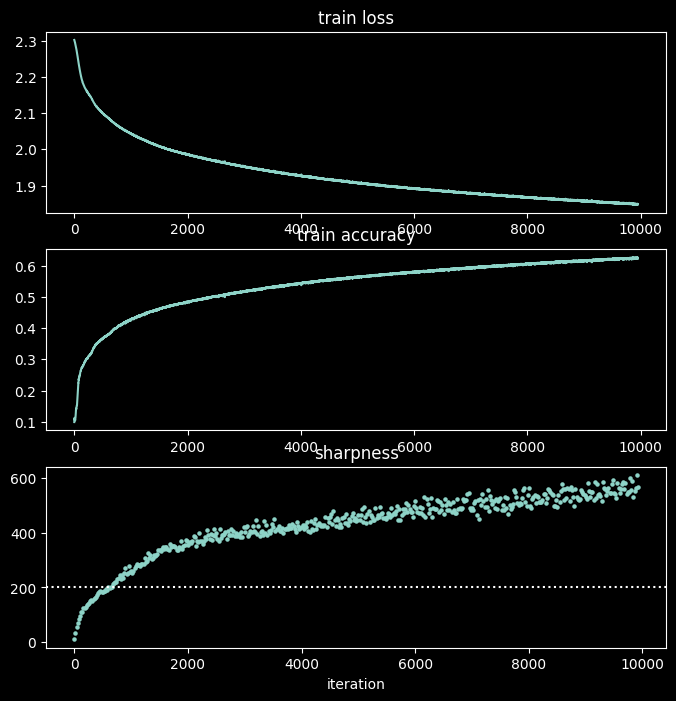

In [31]:
dataset = "cifar10"
arch_id = "cnn-relu"
loss = "ce"
seed = 0

model_params = NGD.EmpiricalNGD.Params(
    lr=0.01,
    fisher_batch_size=1000,
    physical_batch_size=1000,
    epsilon=1e-6,
)

gd_eig_freq = 20

plot(make_directory(dataset, arch_id, loss, model_params), model_params, gd_eig_freq)

Plotting /home/ts/tcs/pr/eos/edge-of-stability/results/cifar10/cnn-relu/mse/seed_0/ngd/lr_0.01__fisher_bs_1000__phys_bs_1000__epsilon_1e-06__momentum_0.99


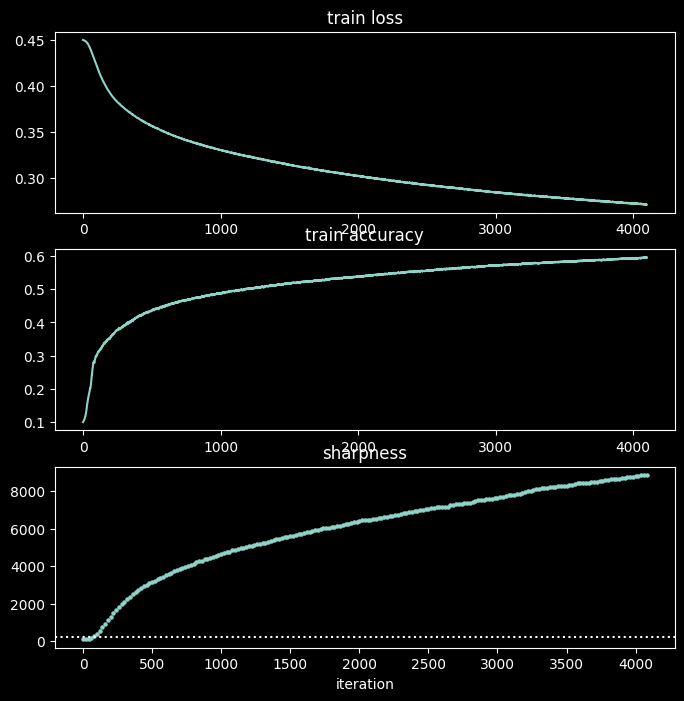

In [32]:
model_params = NGD.EmpiricalNGD.Params(
    lr=0.01,
    fisher_batch_size=1000,
    physical_batch_size=1000,
    epsilon=1e-6,
    momentum=0.99,
)

gd_eig_freq = 20

dataset = "cifar10"
arch_id = "cnn-relu"
loss = "mse"

plot(make_directory(dataset, arch_id, loss, model_params, seed=0), model_params, gd_eig_freq)

Plotting /home/ts/tcs/pr/eos/edge-of-stability/results/cifar10/cnn-relu/mse/seed_1/ngd/lr_0.0001__fisher_bs_1000__phys_bs_3000__epsilon_1e-06__momentum_0.99


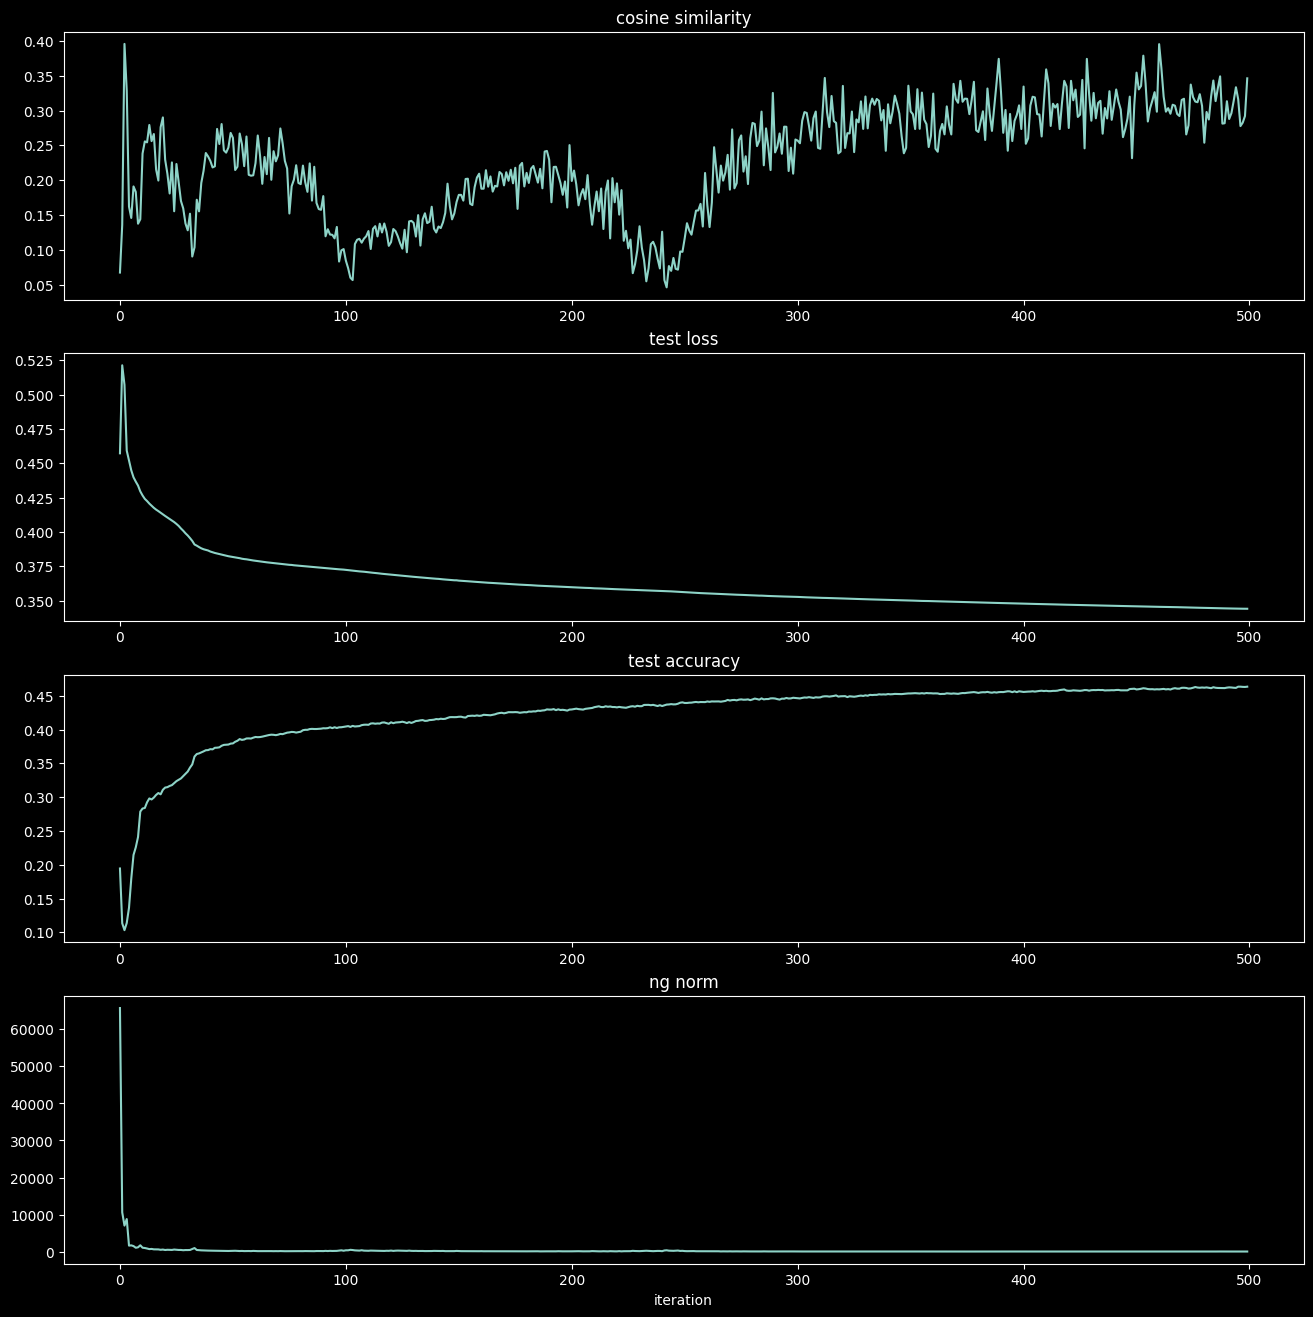

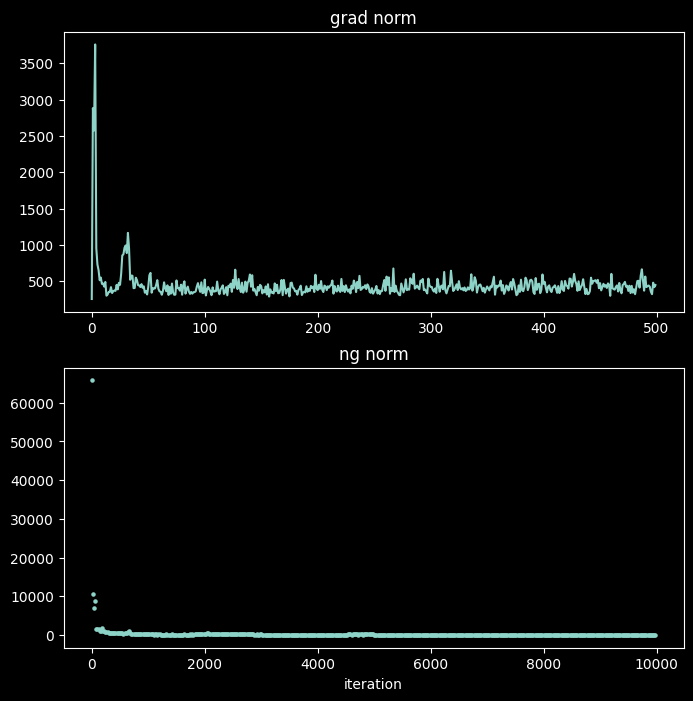

In [ ]:
model_params = NGD.EmpiricalNGD.Params(
    lr=0.0001,
    fisher_batch_size=1000,
    physical_batch_size=3000,
    epsilon=1e-6,
    momentum=0.99,
)

seed = 1

gd_eig_freq = 20

dataset = "cifar10"
arch_id = "cnn-relu"
loss = "mse"

plot2(make_directory(dataset, arch_id, loss, model_params, seed=seed), model_params, gd_eig_freq)